# MFRC Cleaning

This notebook inspects the raw parquet splits, visualizes text coverage and split counts,
and prepares the current standardized MFRC format used in this repo.


In [ ]:
# =========================================================
# CELL PURPOSE:
# Import required libraries, configure notebook display and
# plotting settings, define reusable helper functions, and
# initialise project paths for the MFRC cleaning workflow.
#
# RUN IMPACT:
# Cheap — mostly imports, configuration, and helper definitions.
# =========================================================

from __future__ import annotations


# =========================================================
# STEP 1: STANDARD LIBRARY IMPORTS
# ---------------------------------------------------------
# Import built-in Python modules used throughout the cleaning
# notebook for:
# - path and filesystem handling
# - safe parsing of Python literals
# - CSV and JSON output writing
# - hashing text for duplicate detection
# - regular expression operations
# - file copy / move utilities if needed later
# =========================================================
from pathlib import Path
from ast import literal_eval
import csv
import hashlib
import json
import re
import shutil


# =========================================================
# STEP 2: VISUALISATION IMPORTS
# ---------------------------------------------------------
# Import plotting libraries for quick exploratory analysis,
# class distribution checks, and text-length inspection.
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# STEP 3: CORE DATAFRAME DEPENDENCY
# ---------------------------------------------------------
# pandas is required for the cleaning workflow.
# If unavailable, fail early with a clear error message so the
# notebook does not continue in a broken state.
# =========================================================
try:
    import pandas as pd
except Exception as exc:
    raise RuntimeError("pandas is required to use this cleaning notebook.") from exc


# =========================================================
# STEP 4: NOTEBOOK DISPLAY HELPER
# ---------------------------------------------------------
# display() allows richer notebook output when previewing
# DataFrames during inspection and validation steps.
# =========================================================
from IPython.display import display


# =========================================================
# STEP 5: OPTIONAL PARQUET SUPPORT
# ---------------------------------------------------------
# Attempt to import pyarrow parquet support.
# If unavailable, set pq = None so later code can explicitly
# check whether parquet loading is supported.
# =========================================================
try:
    import pyarrow.parquet as pq
except Exception:
    pq = None


# =========================================================
# STEP 6: NOTEBOOK-WIDE DISPLAY AND PLOT SETTINGS
# ---------------------------------------------------------
# Configure:
# - a clean whitegrid plotting theme
# - wider DataFrame column visibility
# - longer text preview before truncation
#
# This improves EDA readability when working interactively.
# =========================================================
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)


# =========================================================
# STEP 7: PROJECT ROOT DETECTION
# ---------------------------------------------------------
# Search upward from the current working directory until a
# folder containing either "Data" or "data" is found.
#
# Why:
# This makes the notebook portable across environments without
# hardcoding absolute paths.
#
# Returns:
# - the first matching ancestor directory, or
# - the current working directory if no match is found
# =========================================================
def find_project_root() -> Path:
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / "Data").exists() or (candidate / "data").exists():
            return candidate
    return Path.cwd().resolve()


# =========================================================
# STEP 8: DEFINE PROJECT PATHS
# ---------------------------------------------------------
# ROOT:
#   Resolved project base directory
#
# DATA_ROOT:
#   Supports either "Data" or "data" folder naming
#
# RAW_DIR:
#   Location of raw MFRC input files
#
# OUT_DIR:
#   Destination for cleaned MFRC outputs
#
# SAVE_OUTPUTS:
#   Write-control flag; False keeps notebook in preview mode
# =========================================================
ROOT = find_project_root()
DATA_ROOT = ROOT / "Data" if (ROOT / "Data").exists() else ROOT / "data"
RAW_DIR = DATA_ROOT / "raw/mfrc"
OUT_DIR = DATA_ROOT / "processed" / "mfrc"
SAVE_OUTPUTS = False


# =========================================================
# STEP 9: PRINT ACTIVE CONFIGURATION
# ---------------------------------------------------------
# Print resolved paths and save mode so it is immediately
# obvious which directories the notebook is using.
# This helps catch path mistakes early.
# =========================================================
print("Project root:", ROOT)
print("Raw dir:", RAW_DIR)
print("Output dir:", OUT_DIR)
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)


# =========================================================
# STEP 10: DIRECTORY CREATION HELPER
# ---------------------------------------------------------
# Ensure that a directory exists before attempting to write
# files into it.
#
# parents=True:
#   create all missing parent folders
#
# exist_ok=True:
#   do not error if the directory already exists
# =========================================================
def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


# =========================================================
# STEP 11: CSV NORMALISATION HELPER
# ---------------------------------------------------------
# Convert values into CSV-safe representations.
#
# Rules:
# - None becomes an empty string
# - dict/list become JSON strings so nested structures are
#   preserved in a flat file format
# - all other values are returned unchanged
#
# Why:
# CSV does not natively support nested Python objects.
# =========================================================
def normalize_for_csv(value):
    if value is None:
        return ""
    if isinstance(value, (dict, list)):
        return json.dumps(value, ensure_ascii=False)
    return value


# =========================================================
# STEP 12: JSONL WRITER
# ---------------------------------------------------------
# Write a sequence of row dictionaries to newline-delimited
# JSON (JSONL), where each line is a single JSON object.
#
# Why JSONL:
# - convenient for ML/data pipelines
# - easy to stream
# - easy to inspect line by line
# =========================================================
def write_jsonl(path: Path, rows) -> None:
    ensure_dir(path.parent)
    with path.open("w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


# =========================================================
# STEP 13: CSV WRITER
# ---------------------------------------------------------
# Write a sequence of row dictionaries to a CSV file.
#
# Behaviour:
# - ensure output directory exists
# - skip writing if there are no rows
# - infer fieldnames automatically if not provided
# - normalise each value before writing
#
# Fieldname inference:
# Preserves first-seen key order across rows so output columns
# remain stable and readable.
# =========================================================
def write_csv(path: Path, rows, fieldnames=None) -> None:
    ensure_dir(path.parent)

    # Do nothing if there is no data to write
    if not rows:
        return

    # Infer CSV header order if fieldnames are not supplied
    if fieldnames is None:
        fieldnames = []
        seen = set()
        for row in rows:
            for key in row:
                if key not in seen:
                    seen.add(key)
                    fieldnames.append(key)

    # Write header and rows to disk
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow({k: normalize_for_csv(row.get(k)) for k in fieldnames})


# =========================================================
# STEP 14: COUNT PLOT HELPER
# ---------------------------------------------------------
# Plot the top-N most frequent values from a pandas Series.
#
# Processing steps:
# - fill missing values with "<missing>"
# - cast to string for consistent counting
# - compute value counts
# - display the most frequent categories
#
# Typical uses:
# - label distribution
# - split distribution
# - source file frequency
# =========================================================
def plot_count(series, title: str, top_n: int = 15):
    counts = series.fillna("<missing>").astype(str).value_counts().head(top_n)

    # Handle empty input safely
    if counts.empty:
        print(f"No values available for {title}")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=counts.index, y=counts.values, ax=ax, color="#4C72B0")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


# =========================================================
# STEP 15: TEXT-LENGTH PLOT HELPER
# ---------------------------------------------------------
# Plot a histogram of text lengths measured in characters.
#
# Processing steps:
# - fill missing values with empty strings
# - cast everything to string
# - compute character counts
# - display a histogram of lengths
#
# Typical uses:
# - checking for blank/near-blank text
# - spotting unusually long examples
# - comparing input length spread across datasets
# =========================================================
def plot_text_length(series, title: str):
    lengths = series.fillna("").astype(str).str.len()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(lengths, bins=30, ax=ax, color="#55A868")
    ax.set_title(title)
    ax.set_xlabel("characters")
    plt.tight_layout()
    plt.show()

Project root: C:\Users\Ling Jun\Desktop\PSB\AI-ethics
Raw dir: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\raw\mfrc
Output dir: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\processed\mfrc
SAVE_OUTPUTS: False


In [ ]:
# =========================================================
# CELL PURPOSE:
# Load MFRC parquet files from the raw directory, attach
# split/source metadata, consolidate into a single DataFrame,
# and perform initial structural inspection.
#
# RUN IMPACT:
# Moderate — depends on number and size of parquet files.
# =========================================================


# =========================================================
# STEP 1: VALIDATE PARQUET SUPPORT
# ---------------------------------------------------------
# Ensure pyarrow is available before attempting to read
# parquet files.
#
# Why:
# MFRC data is stored in parquet format, so pyarrow is a
# required dependency. Failing early prevents silent errors.
# =========================================================
if pq is None:
    raise RuntimeError("pyarrow is required to read MFRC parquet files.")


# =========================================================
# STEP 2: INITIALISE CONTAINER FOR DATAFRAMES
# ---------------------------------------------------------
# Create a list to store individual DataFrames loaded from
# each parquet file before concatenation.
# =========================================================
frames = []


# =========================================================
# STEP 3: LOAD AND ANNOTATE EACH PARQUET FILE
# ---------------------------------------------------------
# For each parquet file in RAW_DIR:
# - read into a pandas DataFrame
# - assign "split" based on filename (e.g., train/test/dev)
# - assign "source_file" for provenance tracking
# - append to frames list
#
# Why:
# MFRC datasets are often split across multiple files, and
# preserving the split information is critical for modelling.
# =========================================================
for path in sorted(RAW_DIR.glob("*.parquet")):
    df = pq.read_table(path).to_pandas()

    # Use filename (without extension) as split label
    df["split"] = path.stem

    # Track exact source file for traceability
    df["source_file"] = path.name

    frames.append(df)


# =========================================================
# STEP 4: CONCATENATE ALL DATAFRAMES
# ---------------------------------------------------------
# Combine all loaded parquet DataFrames into a single
# unified DataFrame.
#
# ignore_index=True:
# - reset index to ensure a clean continuous index
# =========================================================
raw_df = pd.concat(frames, ignore_index=True)


# =========================================================
# STEP 5: BASIC LOAD VALIDATION
# ---------------------------------------------------------
# Print the shape of the combined dataset to confirm:
# - total number of rows
# - total number of columns
# =========================================================
print("Raw shape:", raw_df.shape)


# =========================================================
# STEP 6: PREVIEW RAW DATA
# ---------------------------------------------------------
# Display the first few rows for quick inspection of:
# - schema
# - column names
# - data formatting
# =========================================================
display(raw_df.head())


# =========================================================
# STEP 7: COLUMN-LEVEL MISSINGNESS SUMMARY
# ---------------------------------------------------------
# Create a table showing:
# - each column name
# - number of missing values per column
#
# Sort descending so the most incomplete columns are
# immediately visible.
# =========================================================
display(
    pd.DataFrame({
        "column": raw_df.columns,
        "missing": raw_df.isna().sum().values
    }).sort_values("missing", ascending=False)
)

Raw shape: (61226, 8)


,text,subreddit,bucket,annotator,annotation,confidence,split,source_file
0,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil a...,europe,French politics,annotator03,Non-Moral,Confident,train,train.parquet
1,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil a...,europe,French politics,annotator01,Purity,Confident,train,train.parquet
2,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil a...,europe,French politics,annotator02,Thin Morality,Confident,train,train.parquet
3,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapot...",europe,French politics,annotator03,Non-Moral,Confident,train,train.parquet
4,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapot...",europe,French politics,annotator00,Non-Moral,Somewhat Confident,train,train.parquet


,column,missing
5,confidence,42
0,text,0
1,subreddit,0
2,bucket,0
3,annotator,0
4,annotation,0
6,split,0
7,source_file,0


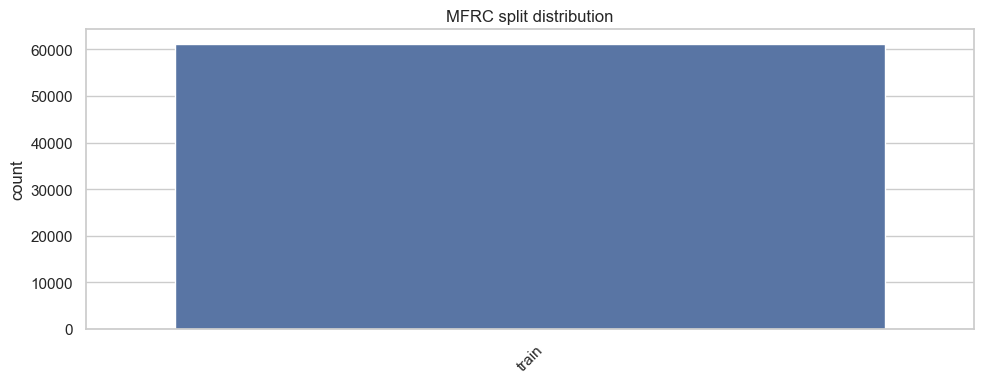

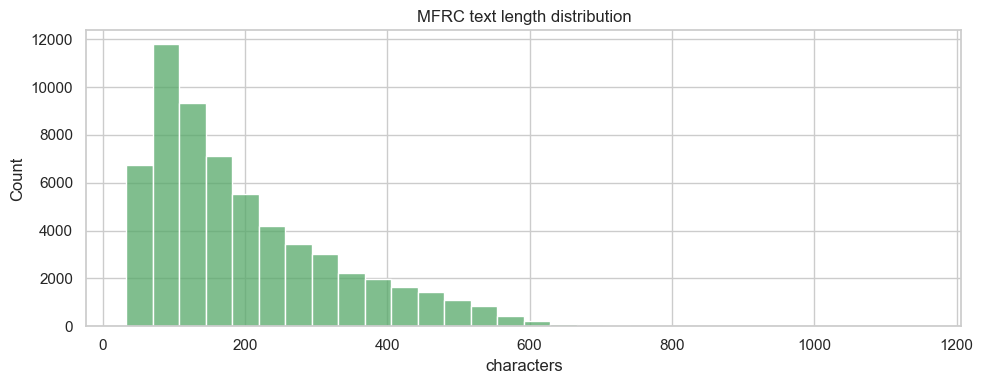

,nunique
annotation,128
subreddit,11
annotator,6
bucket,3
confidence,3


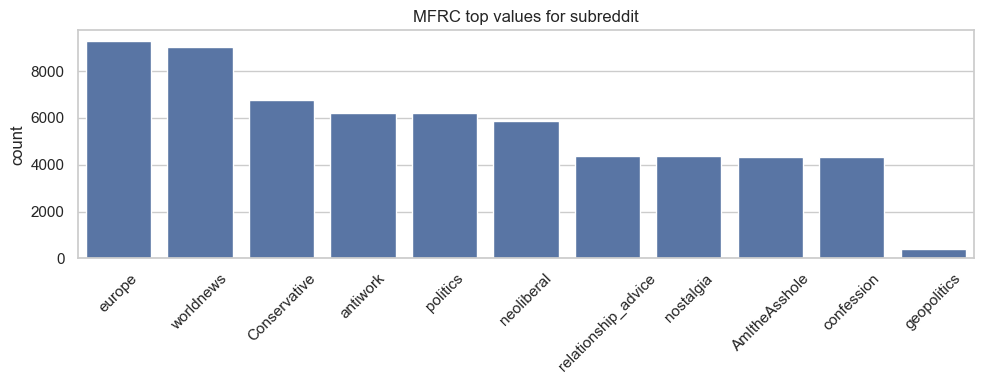

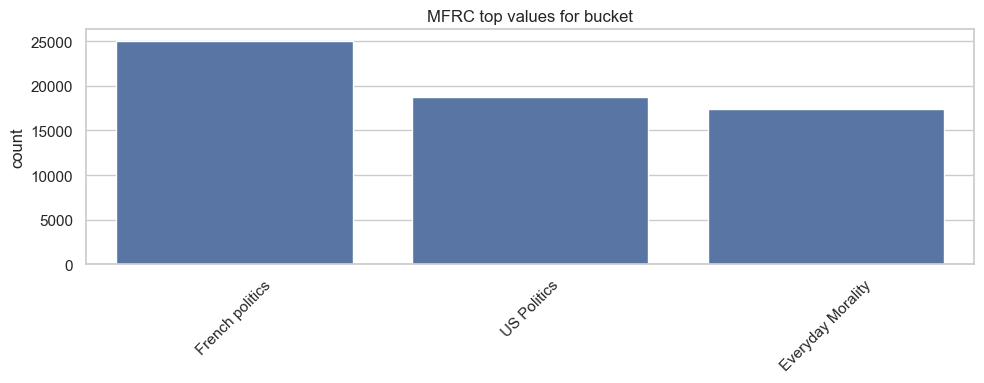

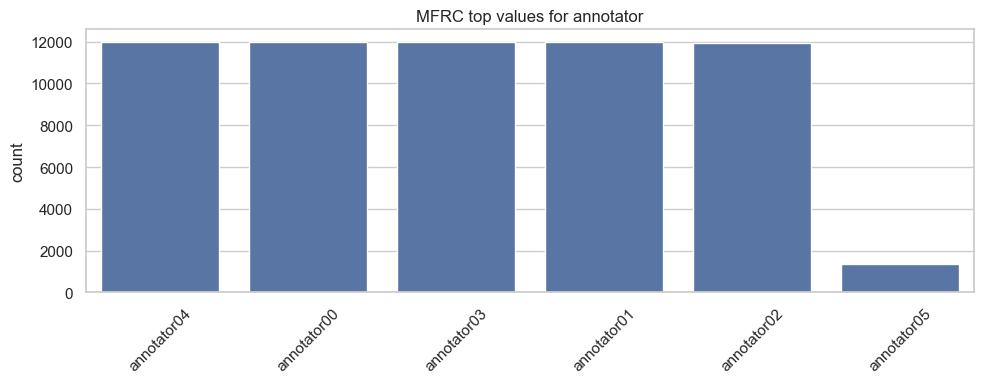

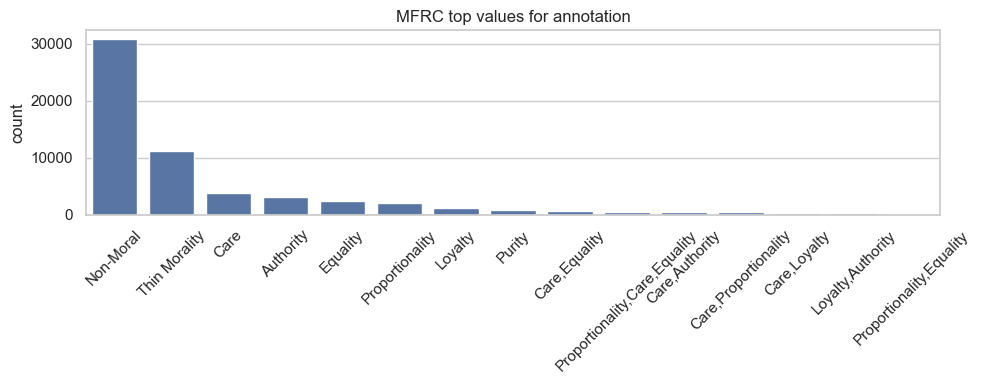

In [ ]:
# =========================================================
# CELL PURPOSE:
# Inspect the main text field, visualise core MFRC dataset
# distributions, and profile metadata columns by uniqueness
# and top categorical values.
#
# RUN IMPACT:
# Cheap to moderate — simple summaries plus a few plots,
# depending on metadata column cardinality.
# =========================================================


# =========================================================
# STEP 1: EXTRACT AND CLEAN TEXT SERIES
# ---------------------------------------------------------
# Build a cleaned text series from the MFRC "text" column.
#
# Cleaning applied:
# - replace missing values with empty strings
# - cast to string for consistency
# - strip surrounding whitespace
#
# Why:
# This creates a stable text field for length analysis and
# blank-value inspection regardless of minor raw inconsistencies.
# =========================================================
text_series = (
    raw_df.get("text", pd.Series(dtype=str))
    .fillna("")
    .astype(str)
    .str.strip()
)


# =========================================================
# STEP 2: PLOT SPLIT DISTRIBUTION
# ---------------------------------------------------------
# Visualise the number of records in each dataset split.
#
# Why:
# This confirms whether train/dev/test-style partitions were
# loaded correctly from the parquet filenames.
# =========================================================
plot_count(
    raw_df["split"],
    "MFRC split distribution"
)


# =========================================================
# STEP 3: PLOT TEXT LENGTH DISTRIBUTION
# ---------------------------------------------------------
# Visualise the distribution of text lengths in characters.
#
# Why:
# Useful for detecting:
# - empty or near-empty examples
# - extremely long examples
# - the general spread of MFRC input lengths
# =========================================================
plot_text_length(
    text_series,
    "MFRC text length distribution"
)


# =========================================================
# STEP 4: IDENTIFY METADATA COLUMNS
# ---------------------------------------------------------
# Collect all columns that are not part of the core cleaned
# schema fields currently under inspection:
# - text
# - split
# - source_file
#
# Why:
# These remaining columns are treated as metadata/features to
# be profiled before deciding what to preserve or transform.
# =========================================================
metadata_columns = [
    c for c in raw_df.columns
    if c not in {"text", "split", "source_file"}
]


# =========================================================
# STEP 5: COMPUTE UNIQUE VALUE COUNTS
# ---------------------------------------------------------
# For each metadata column, calculate the number of distinct
# non-missing values.
#
# Why:
# This helps distinguish:
# - low-cardinality categorical fields
# - high-cardinality identifiers
# - columns that may need special handling later
# =========================================================
unique_counts = pd.Series(
    {col: raw_df[col].nunique(dropna=True) for col in metadata_columns}
).sort_values(ascending=False)


# =========================================================
# STEP 6: DISPLAY TOP METADATA COLUMNS BY CARDINALITY
# ---------------------------------------------------------
# Show the 15 metadata columns with the highest number of
# unique values.
#
# Why:
# This provides a quick profile of how information-rich or
# identifier-like the metadata columns are.
# =========================================================
display(
    unique_counts.to_frame("nunique").head(15)
)


# =========================================================
# STEP 7: PLOT TOP VALUES FOR FIRST FEW OBJECT COLUMNS
# ---------------------------------------------------------
# For the first four metadata columns:
# - check whether the column is object/string-like
# - if so, plot the most frequent values
#
# Why:
# This gives a quick qualitative overview of the most visible
# categorical metadata fields without plotting every column.
#
# Note:
# metadata_columns[:4] uses raw column order, not importance
# order. That is fine for a quick inspection, but if you want
# a more principled EDA pass, you may want to choose columns
# by semantic relevance or cardinality instead.
# =========================================================
for column in metadata_columns[:4]:
    if raw_df[column].dtype == "object":
        plot_count(
            raw_df[column].astype(str),
            f"MFRC top values for {column}"
        )

In [ ]:
# =========================================================
# CELL PURPOSE:
# Build the cleaned MFRC dataset in a standardised schema,
# preserve all non-core fields as metadata, and document the
# current limitation that labels remain nested rather than
# directly exposed for supervised training.
#
# RUN IMPACT:
# Cheap to moderate — DataFrame construction plus row-level
# metadata serialisation.
# =========================================================


# =========================================================
# STEP 1: IDENTIFY METADATA COLUMNS
# ---------------------------------------------------------
# Collect all raw columns that are not part of the cleaned
# core schema fields:
# - text
# - split
# - source_file
#
# Why:
# MFRC contains additional task-relevant information outside
# the core text field, and preserving these columns as metadata
# prevents information loss during cleaning.
# =========================================================
metadata_columns = [
    c for c in raw_df.columns
    if c not in {"text", "split", "source_file"}
]


# =========================================================
# STEP 2: BUILD STANDARDISED CLEANED DATAFRAME
# ---------------------------------------------------------
# Construct the cleaned dataset using the shared schema:
# - text
# - label
# - dataset
# - task
# - split
# - source_file
# - metadata
#
# Field handling:
# - text: cleaned and stripped main input text
# - label: left blank for now because MFRC labels are not yet
#   flattened into a directly supervised column
# - dataset: fixed dataset identifier
# - task: fixed task descriptor for MFRC
# - split/source_file: preserved for provenance and partitioning
# - metadata: stores all remaining raw fields row-by-row
#
# Important:
# This produces a pipeline-compatible structure, but not a fully
# supervised classification dataset yet.
# =========================================================
cleaned_df = pd.DataFrame({
    "text": raw_df["text"].fillna("").astype(str).str.strip(),
    "label": "",
    "dataset": "mfrc",
    "task": "moral_sentiment_multilabel",
    "split": raw_df["split"].astype(str),
    "source_file": raw_df["source_file"].astype(str),
    "metadata": raw_df[metadata_columns].to_dict(orient="records"),
})


# =========================================================
# STEP 3: BASIC CLEANING VALIDATION
# ---------------------------------------------------------
# Print the shape of the cleaned DataFrame to confirm the
# final row/column structure after standardisation.
# =========================================================
print("Cleaned shape:", cleaned_df.shape)


# =========================================================
# STEP 4: PREVIEW CLEANED OUTPUT
# ---------------------------------------------------------
# Display the first few rows to inspect:
# - schema correctness
# - text cleanliness
# - metadata structure
# - expected blank label field
# =========================================================
display(cleaned_df.head())


# =========================================================
# STEP 5: DOCUMENT CURRENT PIPELINE LIMITATION
# ---------------------------------------------------------
# Print an explicit note explaining that this cleaned version
# is currently suitable for prompt-based or metadata-aware use,
# but not yet directly usable for supervised learning within
# the present pipeline.
#
# Why:
# The label signal still lives inside metadata rather than in a
# flattened "label" column expected by the current training code.
# =========================================================
print(
    "MFRC note: this format is prompt-usable, but not directly supervised "
    "in the current pipeline because labels remain nested in metadata."
)

Cleaned shape: (61226, 7)


,text,label,dataset,task,split,source_file,metadata
0,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil a...,,mfrc,moral_sentiment_multilabel,train,train.parquet,"{'subreddit': 'europe', 'bucket': 'French politics', 'annotator': 'annotator03', 'annotation': 'Non-Moral', 'confide..."
1,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil a...,,mfrc,moral_sentiment_multilabel,train,train.parquet,"{'subreddit': 'europe', 'bucket': 'French politics', 'annotator': 'annotator01', 'annotation': 'Purity', 'confidence..."
2,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil a...,,mfrc,moral_sentiment_multilabel,train,train.parquet,"{'subreddit': 'europe', 'bucket': 'French politics', 'annotator': 'annotator02', 'annotation': 'Thin Morality', 'con..."
3,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapot...",,mfrc,moral_sentiment_multilabel,train,train.parquet,"{'subreddit': 'europe', 'bucket': 'French politics', 'annotator': 'annotator03', 'annotation': 'Non-Moral', 'confide..."
4,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapot...",,mfrc,moral_sentiment_multilabel,train,train.parquet,"{'subreddit': 'europe', 'bucket': 'French politics', 'annotator': 'annotator00', 'annotation': 'Non-Moral', 'confide..."


MFRC note: this format is prompt-usable, but not directly supervised in the current pipeline because labels remain nested in metadata.


In [5]:
if SAVE_OUTPUTS:
    write_jsonl(OUT_DIR / "mfrc.jsonl", cleaned_df.to_dict(orient="records"))
    write_csv(OUT_DIR / "mfrc.csv", cleaned_df.to_dict(orient="records"))
    print("Wrote cleaned MFRC outputs to", OUT_DIR)
else:
    print("Preview only. Set SAVE_OUTPUTS = True and rerun this cell to write cleaned files.")


Preview only. Set SAVE_OUTPUTS = True and rerun this cell to write cleaned files.
